**Detección de fallas de
instrumentación y violaciones de seguridad**

**Objetivo**

El objetivo del presente análisis es desarrollar un pipeline de procesamiento y diagnóstico de datos de telemetría vehicular adquiridos a una frecuencia de muestreo de 100 Hz. El análisis considera los canales de aceleración longitudinal (accel_x), aceleración lateral (accel_y), velocidad (speed_kmph), presión de freno (brake_pressure) y posición del acelerador (throttle).

El procedimiento incluye el acondicionamiento de las señales inerciales mediante un filtro pasa-bajas Butterworth de fase cero, el cálculo de la aceleración G combinada, la construcción y diagnóstico del Diagrama G-G, la detección de pérdidas de integridad del sensor inercial y la identificación de eventos de plausibilidad asociados con la aplicación simultánea del freno y el acelerador.

Finalmente, se genera un diagnóstico técnico de los eventos detectados y se proponen acciones de revisión.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, butter, sosfiltfilt, sosfreqz
from google.colab import files
import warnings
warnings.filterwarnings("ignore")

**Cargar el archivo**

In [11]:
uploaded = files.upload()

# Cargar el archivo de telemetría
df = pd.read_csv("data.csv")

# Confirmar que el archivo se cargó correctamente
print("Archivo cargado correctamente: data.csv")
print(f"Número de muestras: {len(df)}")

# Mostrar las primeras filas
df.head()

Saving data.csv to data (4).csv
Archivo cargado correctamente: data.csv
Número de muestras: 30000


,Timestamp,speed_kmph,accel_x,accel_y,brake_pressure,steering_angle,throttle,lane_deviation,phone_usage,headway_distance,reaction_time,behavior_label
0,0.00,36.075.011.221.318.400,5.357.634.189.527.440,7.086.331.754.081.820,23.107.811.717.130.100,-3.169.956.089.764.460,5.312.350.548.150.820,8.518.714.846.208.960,1,17.996.004.566.723.300,14.000.497.114.818.200,Distracted
1,0.01,3.809.053.632.587.040,9.737.639.558.372.700,443.120.980.457.895,3.696.113.666.604.910,-2.438.008.153.545.240,363.839.043.667.284,14.594.951.042.899.000,1,2.990.418.224.637.660,14.285.366.907.550.100,Distracted
2,0.02,7.131.444.489.805.500,1.0,7.893.752.668.601.110,7.973.408.727.001.500,-61.002.378.508.739.100,7.811.050.734.408.910,2.547.229.621.314.540,0,11.126.012.259.878.500,4.069.498.440.658.550,Aggressive
3,0.03,864.859.970.442.183,1.0,2.219.655.748.807.440,4.500.700.186.827.250,17.886.191.415.642.200,8.279.493.538.933.530,911.664.008.515.404,0,11.064.505.213.109.300,5.399.642.642.424.280,Aggressive
4,0.04,528.167.773.592.694,-201.762.839.915.681,560.619.152.373.741,38.759.611.619.342.800,-4.104.322.758.391.770,6.143.237.535.593.530,15.912.437.280.989.900,1,21.967.570.454.820.600,1.369.907.717.434.280,Distracted


**Configuración inicial**

In [12]:
FS = 100.0                     # Frecuencia de muestreo [Hz]
NYQUIST = FS / 2.0             # Frecuencia de Nyquist [Hz]
DT = 1.0 / FS                  # Periodo de muestreo [s]

# Crear vector de tiempo
df["time"] = np.arange(len(df)) / FS

print(f"Frecuencia de muestreo: {FS} Hz")
print(f"Frecuencia de Nyquist: {NYQUIST} Hz")

Frecuencia de muestreo: 100.0 Hz
Frecuencia de Nyquist: 50.0 Hz


Debido a que el sistema registra información a una frecuencia de 100 Hz, cada muestra corresponde a un intervalo temporal de 0.01 segundos.

A partir del número total de muestras se construye un vector de tiempo que permite asociar cada registro con su instante correspondiente. Este vector será utilizado posteriormente para localizar con precisión eventos dinámicos, fallas de sensores y violaciones de plausibilidad.

**Frecuencia de corte y Nyquist**

Con el propósito de seleccionar adecuadamente la frecuencia de corte del filtro, se analiza el contenido frecuencial de las señales de aceleración.

La frecuencia de muestreo del sistema es de 100 Hz, por lo que, de acuerdo con el criterio de Nyquist, la frecuencia máxima que puede representarse es de 50 Hz.



**Validación de columnas requeridas**

In [13]:
required_cols = ["accel_x", "accel_y", "speed_kmph", "brake_pressure", "throttle"]
missing = [col for col in required_cols if col not in df.columns]
if missing:
    raise ValueError(f"Faltan columnas: {missing}")
else:
    print("Todas las columnas requeridas están presentes.")

Todas las columnas requeridas están presentes.


**Información general del dataset**

In [14]:
n_samples = len(df)
duration = n_samples / FS

print(f"Número de muestras: {n_samples}")
print(f"Duración total: {duration:.2f} s")
print("\nColumnas disponibles:")
print(df.columns.tolist())
print("\nPrimeras filas:")
print(df.head())
print("\nCantidad de valores faltantes por canal:")
print(df[required_cols].isnull().sum())
print("\nEstadísticas descriptivas:")
print(df[required_cols].describe())

Número de muestras: 30000
Duración total: 300.00 s

Columnas disponibles:
['Timestamp', 'speed_kmph', 'accel_x', 'accel_y', 'brake_pressure', 'steering_angle', 'throttle', 'lane_deviation', 'phone_usage', 'headway_distance', 'reaction_time', 'behavior_label', 'time']

Primeras filas:
   Timestamp              speed_kmph                accel_x  \
0       0.00  36.075.011.221.318.400  5.357.634.189.527.440   
1       0.01   3.809.053.632.587.040  9.737.639.558.372.700   
2       0.02   7.131.444.489.805.500                    1.0   
3       0.03     864.859.970.442.183                    1.0   
4       0.04     528.167.773.592.694   -201.762.839.915.681   

                 accel_y          brake_pressure           steering_angle  \
0  7.086.331.754.081.820  23.107.811.717.130.100   -3.169.956.089.764.460   
1    443.120.980.457.895   3.696.113.666.604.910   -2.438.008.153.545.240   
2  7.893.752.668.601.110   7.973.408.727.001.500  -61.002.378.508.739.100   
3  2.219.655.748.807.440   4

Se observa que los datos numéricos como las aceleraciones, velocidad, presión de freno y acelerador han sido interpretados como cadenas de texto debido a la presencia de puntos como separadores de miles. Es necesario convertir estas columnas a un formato numérico para poder realizar cálculos y graficaciones correctamente. Se utilizará `pd.to_numeric` y se eliminarán los puntos.

**Gráficas de señales originales**

Rangos después de la limpieza:

accel_x: mín = -2.468, máx = 2.500
accel_y: mín = -2.492, máx = 2.500
speed_kmph: mín = 20.000, máx = 118.440
brake_pressure: mín = 10.003, máx = 99.994
throttle: mín = 20.001, máx = 99.995


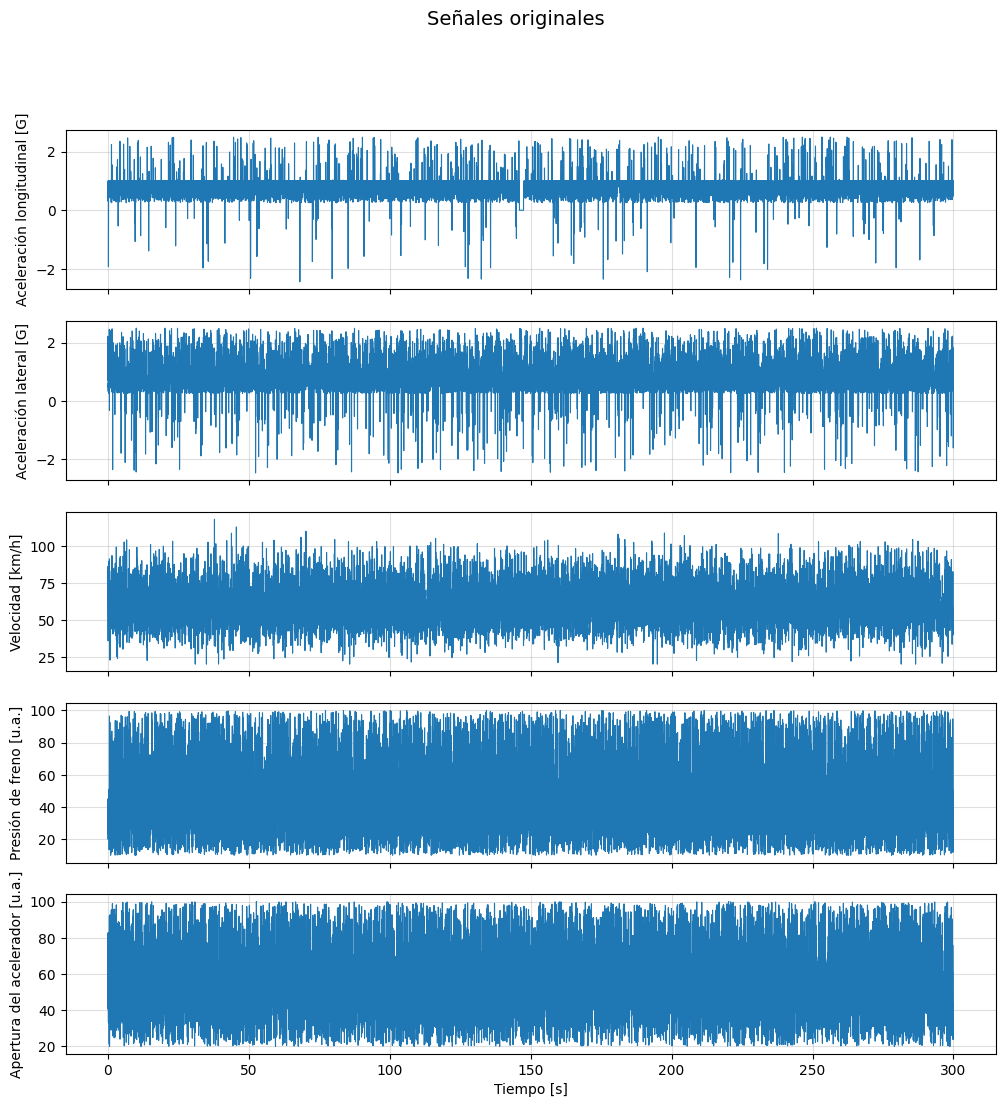

In [15]:
# ============================================================
# LIMPIEZA DE DATOS Y GRÁFICAS DE SEÑALES ORIGINALES
# ============================================================

channels = [
    "accel_x",
    "accel_y",
    "speed_kmph",
    "brake_pressure",
    "throttle"
]

# Límites físicos aproximados utilizados para reconstruir
# los números que contienen múltiples puntos
limits = {
    "accel_x": 2.5,
    "accel_y": 2.5,
    "speed_kmph": 200.0,
    "brake_pressure": 100.0,
    "throttle": 100.0
}

def clean_number(value, max_abs):
    """
    Convierte valores corruptos con múltiples puntos
    a valores numéricos dentro de un rango físicamente plausible.
    """

    if pd.isna(value):
        return float("nan")

    text = str(value).strip()

    # Si ya es un número normal, por ejemplo 1.0 o -0.5
    if text.count(".") <= 1:
        try:
            return float(text)
        except ValueError:
            return float("nan")

    # Detectar signo
    sign = -1 if text.startswith("-") else 1

    # Eliminar los puntos problemáticos
    digits = "".join(c for c in text if c.isdigit())

    if not digits:
        return float("nan")

    value_numeric = sign * float(digits)

    # Reconstruir la escala decimal utilizando
    # el rango esperado para cada variable
    while abs(value_numeric) > max_abs:
        value_numeric /= 10.0

    return value_numeric


# Limpiar cada canal
for col in channels:
    df[col] = df[col].apply(
        lambda x: clean_number(x, limits[col])
    )


# Verificar los rangos después de la limpieza
print("Rangos después de la limpieza:\n")

for col in channels:
    print(
        f"{col}: "
        f"mín = {df[col].min():.3f}, "
        f"máx = {df[col].max():.3f}"
    )


# ============================================================
# GRÁFICAS
# ============================================================

titles = [
    "Aceleración longitudinal [G]",
    "Aceleración lateral [G]",
    "Velocidad [km/h]",
    "Presión de freno [u.a.]",
    "Apertura del acelerador [u.a.]"
]

# Reducir puntos únicamente para visualización
max_plot_points = 10000
step = max(1, len(df) // max_plot_points)

df_plot = df.iloc[::step]

fig, axes = plt.subplots(
    5,
    1,
    figsize=(12, 12),
    sharex=True
)

for ax, col, title in zip(axes, channels, titles):

    ax.plot(
        df_plot["time"],
        df_plot[col],
        linewidth=0.8
    )

    ax.set_ylabel(title)
    ax.grid(True, alpha=0.4)

axes[-1].set_xlabel("Tiempo [s]")

fig.suptitle(
    "Señales originales",
    fontsize=14
)

plt.show()

Se observan las cinco variables en el dominio del tiempo. Las aceleraciones presentan fluctuaciones de alta frecuencia que podrían corresponder a vibraciones estructurales. La velocidad muestra una tendencia general creciente, mientras que el freno y el acelerador presentan picos y mesetas que reflejan las acciones del piloto. Estas gráficas permiten identificar visualmente posibles valores atípicos o comportamientos anómalos.

**Análisis espectral (PSD) de las aceleraciones**

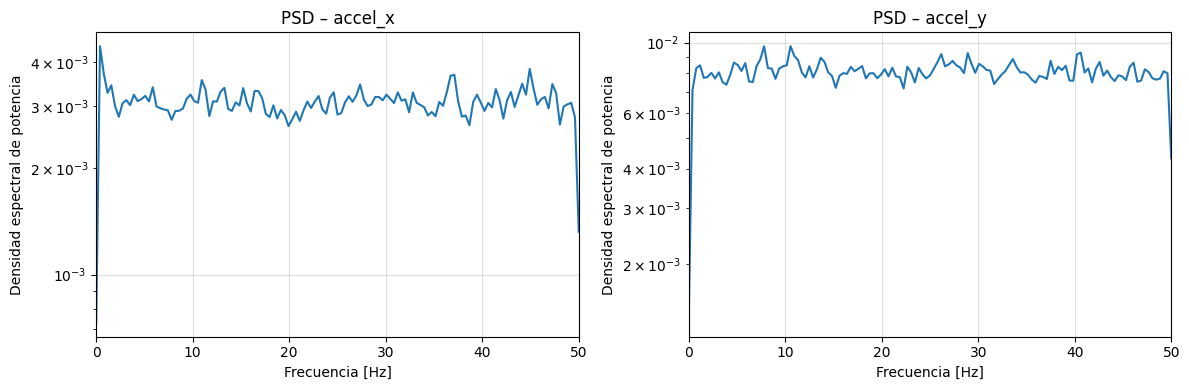

In [18]:
def plot_psd(data, title, ax):
    # Convertir explícitamente la Serie de Pandas a NumPy
    data = np.asarray(data, dtype=float)

    # Eliminar valores NaN o infinitos
    data = data[np.isfinite(data)]

    # Calcular PSD
    f, Pxx = welch(
        data,
        fs=FS,
        nperseg=min(256, len(data))
    )

    ax.semilogy(f, Pxx)
    ax.set_xlim(0, 50)
    ax.set_xlabel("Frecuencia [Hz]")
    ax.set_ylabel("Densidad espectral de potencia")
    ax.set_title(title)
    ax.grid(True, alpha=0.4)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_psd(
    df["accel_x"].to_numpy(),
    "PSD – accel_x",
    axes[0]
)

plot_psd(
    df["accel_y"].to_numpy(),
    "PSD – accel_y",
    axes[1]
)

plt.tight_layout()
plt.show()

La densidad espectral de potencia muestra cómo se distribuye la energía de las señales en función de la frecuencia. Se aprecia que la mayor parte de la energía se concentra en las bajas frecuencias (por debajo de unos pocos hercios), que corresponden a las maniobras del vehículo. Las componentes de alta frecuencia (por encima de 5‑10 Hz) son atribuibles a vibraciones estructurales, ruido de los sensores o resonancias. Este análisis justifica la **elección de un filtro pasa‑bajas** con frecuencia de corte alrededor de 5 Hz para conservar la dinámica principal y atenuar el ruido no deseado.

**Diseño del filtro Butterworth pasa‑bajas**

Se utiliza un filtro **Butterworth** de orden 4 y frecuencia de corte de 5 Hz. El orden 4 ofrece un equilibrio entre atenuación y distorsión de fase. La frecuencia de corte se selecciona a partir del análisis espectral, donde las componentes relevantes se concentran por debajo de 5 Hz.

In [19]:
ORDER = 4
FC = 5.0  # Frecuencia de corte [Hz]
sos = butter(ORDER, FC, btype="low", fs=FS, output="sos")


1.   Un filtro pasa‑bajas deja pasar las frecuencias inferiores a la frecuencia de corte y atenúa las superiores.
2.   Butterworth proporciona una respuesta plana en la banda de paso, minimizando la ondulación.
3. El orden controla la pendiente de atenuación; un orden más alto elimina mejor las altas frecuencias pero puede introducir más retraso de fase.
4. Con output="sos" se obtienen secciones de segundo orden, que son numéricamente más estables.




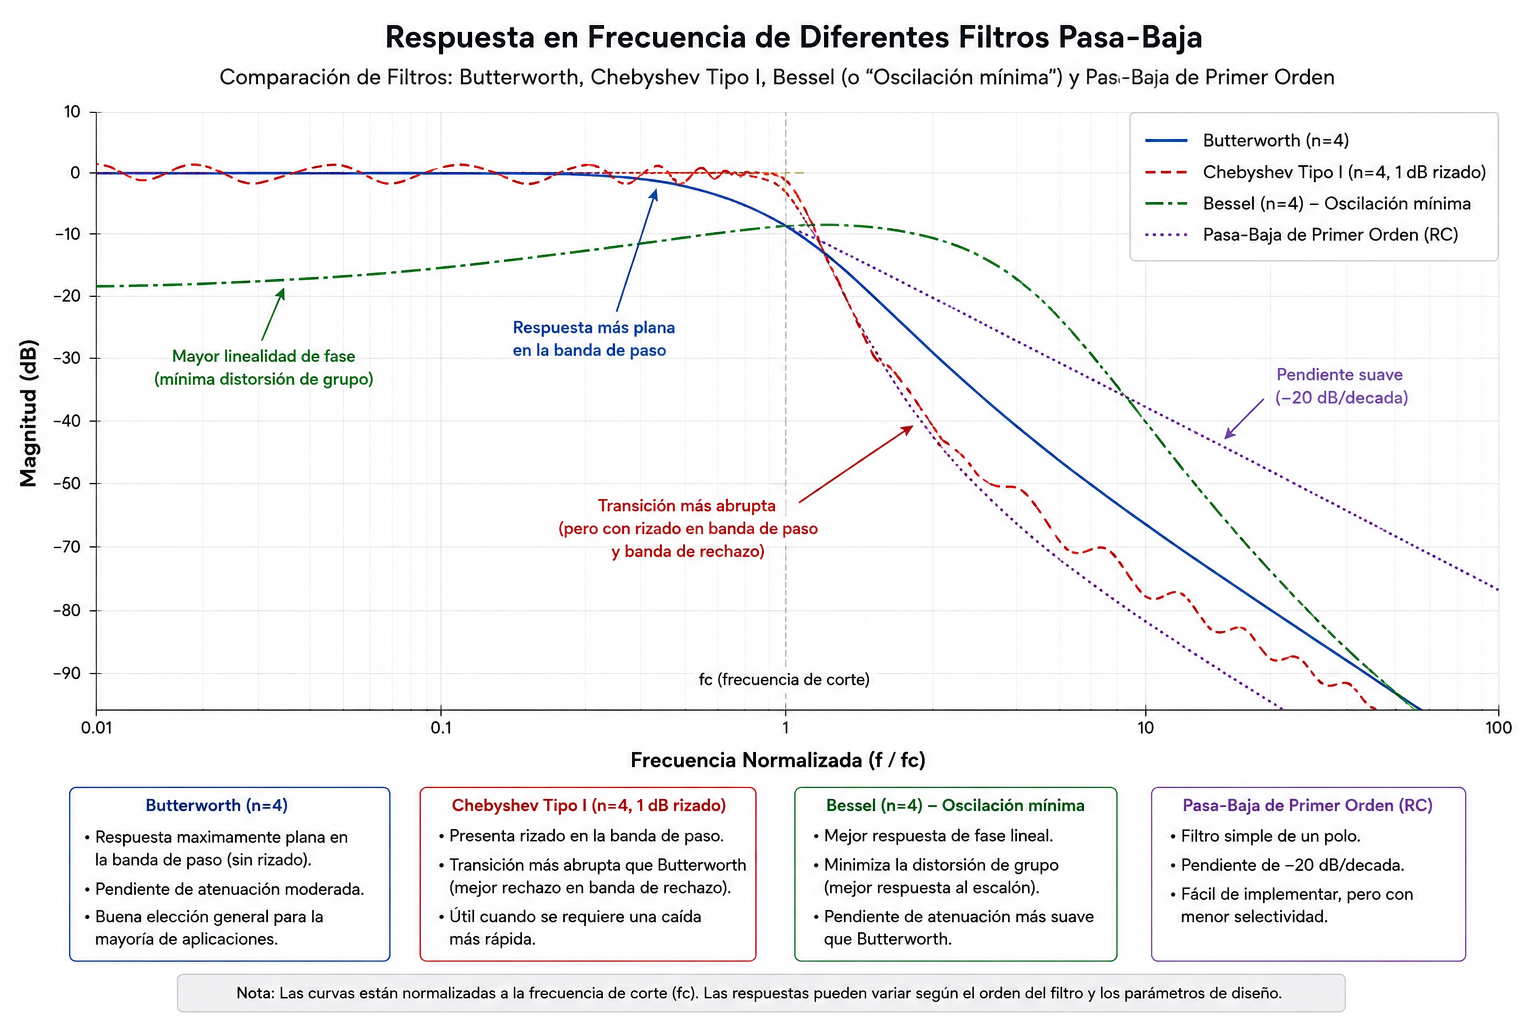

**Respuesta en frecuencia del filtro**

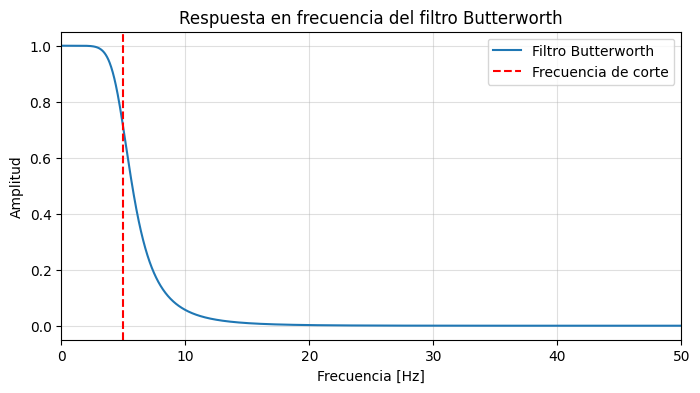

In [22]:
w, h = sosfreqz(sos, worN=2000, fs=FS)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(w, np.abs(h), label="Filtro Butterworth")
ax.axvline(
    FC,
    color="red",
    linestyle="--",
    label="Frecuencia de corte"
)

ax.set_xlim(0, 50)
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Amplitud")
ax.set_title("Respuesta en frecuencia del filtro Butterworth")
ax.grid(True, alpha=0.4)
ax.legend()

plt.show()

La gráfica muestra la ganancia del filtro en función de la frecuencia. En la frecuencia de corte (5 Hz), la amplitud es aproximadamente 0.707 (‑3 dB), que es el punto característico de un filtro Butterworth. Las frecuencias superiores a 5 Hz son atenuadas progresivamente, mientras que las inferiores se mantienen prácticamente inalteradas.

**Aplicación del filtro**

In [23]:
# Crear copias para preservar los originales
df["accel_x_original"] = df["accel_x"].copy()
df["accel_y_original"] = df["accel_y"].copy()

# Interpolar valores NaN para poder filtrar (solo para la señal filtrada)
x_interp = df["accel_x"].interpolate(method="linear", limit_direction="both")
y_interp = df["accel_y"].interpolate(method="linear", limit_direction="both")

df["accel_x_filtered"] = sosfiltfilt(sos, x_interp)
df["accel_y_filtered"] = sosfiltfilt(sos, y_interp)

Al no introducir retraso temporal, se mantiene la sincronización entre las señales de aceleración, velocidad, freno y acelerador. Esto es esencial para correlacionar correctamente los eventos dinámicos y para el cálculo de la aceleración combinada en cada instante.

**Comparación original vs filtrada**

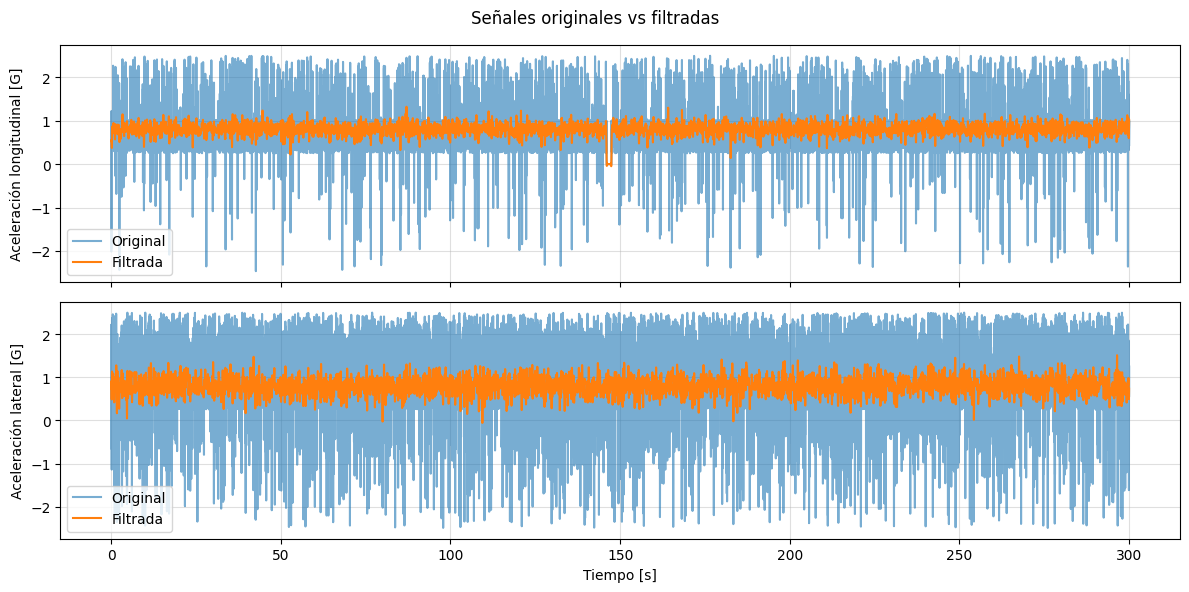

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df["time"], df["accel_x_original"], label="Original", alpha=0.6)
axes[0].plot(df["time"], df["accel_x_filtered"], label="Filtrada", linewidth=1.5)
axes[0].set_ylabel("Aceleración longitudinal [G]")
axes[0].grid(True, alpha=0.4)
axes[0].legend()

axes[1].plot(df["time"], df["accel_y_original"], label="Original", alpha=0.6)
axes[1].plot(df["time"], df["accel_y_filtered"], label="Filtrada", linewidth=1.5)
axes[1].set_ylabel("Aceleración lateral [G]")
axes[1].set_xlabel("Tiempo [s]")
axes[1].grid(True, alpha=0.4)
axes[1].legend()

plt.suptitle("Señales originales vs filtradas")
plt.tight_layout()
plt.show()

**Componentes eliminadas**

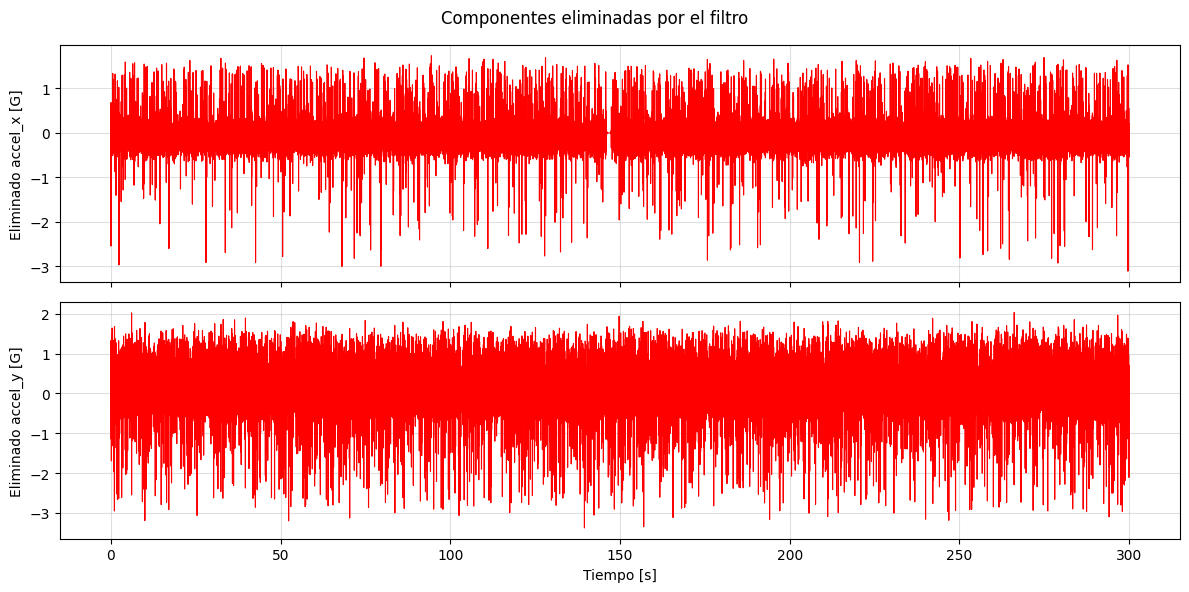

In [25]:
df["removed_x"] = df["accel_x_original"] - df["accel_x_filtered"]
df["removed_y"] = df["accel_y_original"] - df["accel_y_filtered"]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(df["time"], df["removed_x"], color="red", linewidth=0.8)
axes[0].set_ylabel("Eliminado accel_x [G]")
axes[0].grid(True, alpha=0.4)
axes[1].plot(df["time"], df["removed_y"], color="red", linewidth=0.8)
axes[1].set_ylabel("Eliminado accel_y [G]")
axes[1].set_xlabel("Tiempo [s]")
axes[1].grid(True, alpha=0.4)
plt.suptitle("Componentes eliminadas por el filtro")
plt.tight_layout()
plt.show()

Las señales filtradas presentan un aspecto más suave, eliminando las oscilaciones de alta frecuencia. Las componentes eliminadas son esencialmente las variaciones rápidas que no corresponden a la dinámica general del vehículo. El filtro reduce el ruido sin distorsionar los picos principales de aceleración.

**Aceleración combinada (G)**

Se calcula la G combinada utilizando las señales filtradas, ya que es la magnitud que se emplea oficialmente para el diagnóstico.

In [26]:
df["G_raw"] = np.sqrt(df["accel_x_original"]**2 + df["accel_y_original"]**2)
df["G_filtered"] = np.sqrt(df["accel_x_filtered"]**2 + df["accel_y_filtered"]**2)

# Máxima G filtrada
max_g = df["G_filtered"].max()
max_idx = df["G_filtered"].idxmax()
max_time = df.loc[max_idx, "time"]

print(f"G combinada máxima filtrada: {max_g:.3f} G")
print(f"Timestamp: {max_time:.3f} s")
print(f"Índice: {max_idx}")

G combinada máxima filtrada: 1.849 G
Timestamp: 87.020 s
Índice: 8702


**Gráfica comparativa**

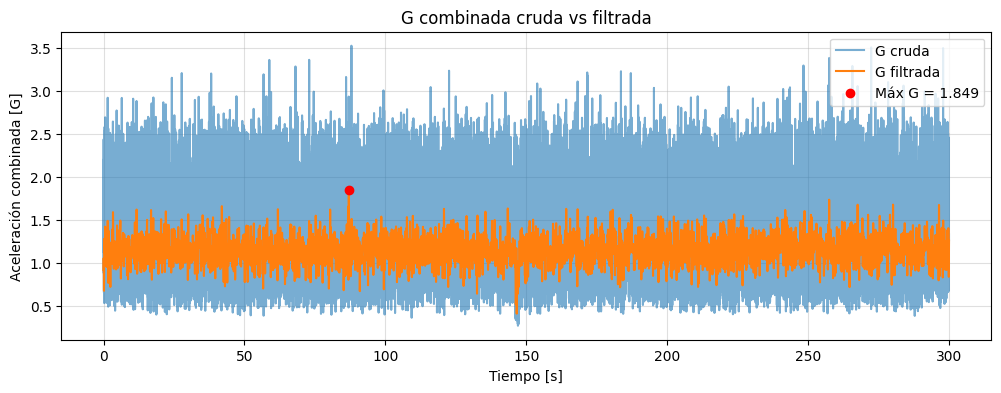

In [27]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["time"], df["G_raw"], label="G cruda", alpha=0.6)
ax.plot(df["time"], df["G_filtered"], label="G filtrada", linewidth=1.5)
ax.scatter(max_time, max_g, color="red", zorder=5, label=f"Máx G = {max_g:.3f}")
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("Aceleración combinada [G]")
ax.set_title("G combinada cruda vs filtrada")
ax.grid(True, alpha=0.4)
ax.legend()
plt.show()

La G cruda presenta picos más elevados debido al ruido. La G filtrada muestra una envolvente más realista de las cargas. El máximo de la señal filtrada es el valor que debe emplearse para evaluar el desempeño del vehículo, ya que no está contaminado por vibraciones espurias.

**Diagrama G‑G (huella de fricción)**

Se emplean exclusivamente las aceleraciones filtradas.

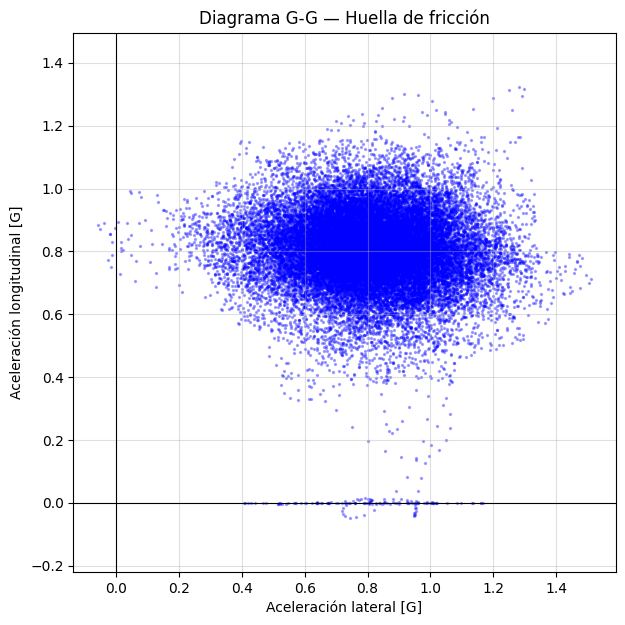

In [28]:
long_g = df["accel_x_filtered"]
lat_g = df["accel_y_filtered"]

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(lat_g, long_g, s=2, alpha=0.3, color="blue")
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.grid(True, alpha=0.4)
ax.set_xlabel("Aceleración lateral [G]")
ax.set_ylabel("Aceleración longitudinal [G]")
ax.set_title("Diagrama G-G — Huella de fricción")
ax.axis("equal")
plt.show()

El diagrama G‑G muestra la relación entre aceleración lateral y longitudinal. Los puntos se distribuyen en los cuatro cuadrantes: aceleración y frenado, combinados con curvas a izquierda y derecha. La forma y extensión de la nube indican el agarre disponible y la capacidad del vehículo para combinar cargas.

**Envolvente y asimetría lateral**

Se calcula una envolvente robusta mediante percentiles para evitar que valores atípicos distorsionen el análisis.

In [29]:
# Separación por signo de la lateral
lat_pos = lat_g[lat_g > 0]
lat_neg = lat_g[lat_g < 0]
long_pos = long_g[long_g > 0]
long_neg = long_g[long_g < 0]

G_left = np.percentile(np.abs(lat_pos), 95) if len(lat_pos) > 0 else np.nan
G_right = np.percentile(np.abs(lat_neg), 95) if len(lat_neg) > 0 else np.nan
G_accel = np.percentile(long_pos, 95) if len(long_pos) > 0 else np.nan
G_braking = np.percentile(np.abs(long_neg), 95) if len(long_neg) > 0 else np.nan

asymmetry = (G_left - G_right) / max(G_left, G_right) if max(G_left, G_right) > 0 else 0
asymmetry_percent = asymmetry * 100

print(f"G lateral izquierda (95%): {G_left:.3f} G")
print(f"G lateral derecha  (95%): {G_right:.3f} G")
print(f"Asimetría lateral: {asymmetry_percent:.2f} %")

G lateral izquierda (95%): 1.113 G
G lateral derecha  (95%): 0.055 G
Asimetría lateral: 95.05 %


**Gráfica de envolvente**

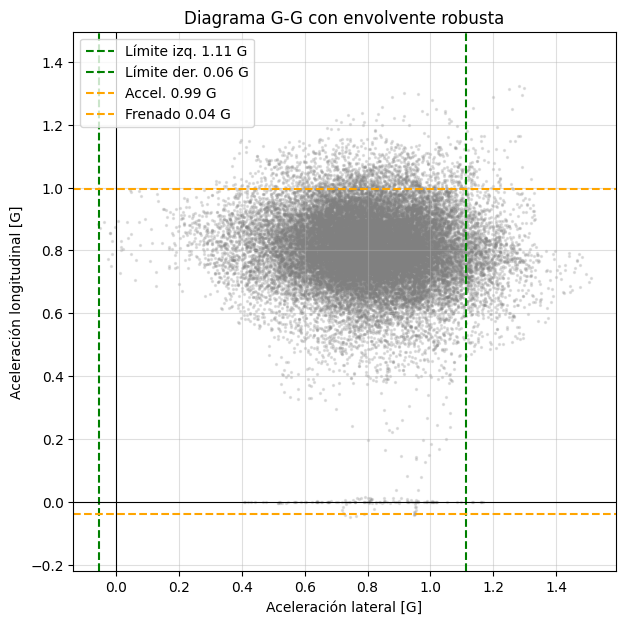

In [30]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(lat_g, long_g, s=2, alpha=0.2, color="gray")

# Rectángulo envolvente (simplificado)
ax.axvline(G_left, color="green", linestyle="--", label=f"Límite izq. {G_left:.2f} G")
ax.axvline(-G_right, color="green", linestyle="--", label=f"Límite der. {G_right:.2f} G")
ax.axhline(G_accel, color="orange", linestyle="--", label=f"Accel. {G_accel:.2f} G")
ax.axhline(-G_braking, color="orange", linestyle="--", label=f"Frenado {G_braking:.2f} G")

ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.grid(True, alpha=0.4)
ax.set_xlabel("Aceleración lateral [G]")
ax.set_ylabel("Aceleración longitudinal [G]")
ax.set_title("Diagrama G-G con envolvente robusta")
ax.legend()
ax.axis("equal")
plt.show()

Los límites representan el percentil 95 de las cargas en cada dirección. La asimetría lateral indica si el vehículo es capaz de generar más agarre en un sentido que en el otro.

**Diagnóstico del diagrama G‑G**

In [31]:
if abs(asymmetry_percent) < 5:
    diagnosis = "comportamiento aproximadamente equilibrado."
elif abs(asymmetry_percent) < 15:
    diagnosis = "asimetría moderada que requiere revisión."
else:
    diagnosis = "asimetría direccional significativa."

print("DIAGNÓSTICO DEL DIAGRAMA G-G")
print("Resultado calculado:")
print(f"  Asimetría lateral: {asymmetry_percent:.2f} %")
print(f"  Diagnóstico: {diagnosis}")
print("\nPosibles causas:")
print("  - Set-up del vehículo (presión de neumáticos, alineación, distribución de cargas).")
print("  - Condiciones del circuito (predominancia de curvas en una dirección).")
print("  - Instrumentación (offset del acelerómetro, montaje inclinado).")

DIAGNÓSTICO DEL DIAGRAMA G-G
Resultado calculado:
  Asimetría lateral: 95.05 %
  Diagnóstico: asimetría direccional significativa.

Posibles causas:
  - Set-up del vehículo (presión de neumáticos, alineación, distribución de cargas).
  - Condiciones del circuito (predominancia de curvas en una dirección).
  - Instrumentación (offset del acelerómetro, montaje inclinado).


**Detección de pérdida de señal (IMU)**

Se analizan las señales originales accel_x y accel_y para encontrar:

Valores NaN.

Flatline (valores constantes durante ≥ 20 muestras).

Posible saturación (valores muy cercanos al máximo o mínimo del rango).

In [32]:
def consecutive_mask(mask):
    """Devuelve lista de (inicio, fin) para segmentos donde mask es True."""
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return []
    segments = []
    start = idx[0]
    for i in range(1, len(idx)):
        if idx[i] != idx[i-1] + 1:
            segments.append((start, idx[i-1]))
            start = idx[i]
    segments.append((start, idx[-1]))
    return segments

# 1. NaN
nan_mask_x = df["accel_x_original"].isna()
nan_mask_y = df["accel_y_original"].isna()
nan_segments = consecutive_mask(nan_mask_x | nan_mask_y)

# 2. Flatline (valores iguales durante 20 muestras consecutivas)
def flatline_segments(signal, min_len=20):
    flat = np.zeros(len(signal), dtype=bool)
    diff = signal.diff().fillna(1)  # cualquier valor no nulo
    # marcamos donde diff == 0
    for i in range(len(signal)-min_len+1):
        if np.all(signal.iloc[i:i+min_len] == signal.iloc[i]):
            flat[i:i+min_len] = True
    return consecutive_mask(flat)

flat_x = flatline_segments(df["accel_x_original"])
flat_y = flatline_segments(df["accel_y_original"])
all_flat = flat_x + flat_y

# 3. Posible saturación (valores en los extremos del rango)
q01 = df["accel_x_original"].quantile(0.01)
q99 = df["accel_x_original"].quantile(0.99)
sat_x = (df["accel_x_original"] <= q01) | (df["accel_x_original"] >= q99)
q01_y = df["accel_y_original"].quantile(0.01)
q99_y = df["accel_y_original"].quantile(0.99)
sat_y = (df["accel_y_original"] <= q01_y) | (df["accel_y_original"] >= q99_y)
sat_segments = consecutive_mask(sat_x | sat_y)

print("EVENTOS DE PÉRDIDA DE SEÑAL (NaN, flatline, saturación)")
print(f"  Segmentos con NaN: {len(nan_segments)}")
print(f"  Segmentos flatline: {len(all_flat)}")
print(f"  Segmentos de posible saturación: {len(sat_segments)}")

# Mostrar los primeros segmentos de cada tipo (si existen)
if len(nan_segments) > 0:
    print("\nPrimeros segmentos NaN:")
    for s, e in nan_segments[:3]:
        print(f"  Muestra {s}-{e}, tiempo {df.loc[s,'time']:.3f}-{df.loc[e,'time']:.3f} s")
if len(all_flat) > 0:
    print("\nPrimeros segmentos flatline:")
    for s, e in all_flat[:3]:
        print(f"  Muestra {s}-{e}, tiempo {df.loc[s,'time']:.3f}-{df.loc[e,'time']:.3f} s")

EVENTOS DE PÉRDIDA DE SEÑAL (NaN, flatline, saturación)
  Segmentos con NaN: 6
  Segmentos flatline: 1
  Segmentos de posible saturación: 1140

Primeros segmentos NaN:
  Muestra 2462-2462, tiempo 24.620-24.620 s
  Muestra 14189-14189, tiempo 141.890-141.890 s
  Muestra 16160-16160, tiempo 161.600-161.600 s

Primeros segmentos flatline:
  Muestra 14597-14746, tiempo 145.970-147.460 s


**Gráfica del evento de pérdida de señal más largo**

In [33]:
if len(nan_segments) > 0:
    # Tomar el segmento más largo
    max_len = 0
    best = None
    for s, e in nan_segments:
        if e - s > max_len:
            max_len = e - s
            best = (s, e)
    if best is not None:
        s, e = best
        start = max(0, s - 100)
        end = min(len(df), e + 100)
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(df["time"].iloc[start:end], df["accel_x_original"].iloc[start:end], label="accel_x")
        ax.plot(df["time"].iloc[start:end], df["accel_y_original"].iloc[start:end], label="accel_y")
        ax.axvspan(df.loc[s, "time"], df.loc[e, "time"], color="red", alpha=0.3, label="Pérdida")
        ax.set_xlabel("Tiempo [s]")
        ax.set_ylabel("Aceleración [G]")
        ax.set_title("Evento de pérdida de señal (NaN) más largo")
        ax.grid(True, alpha=0.4)
        ax.legend()
        plt.show()
else:
    print("No se detectaron eventos de pérdida de señal por NaN.")

**Detección de posible saturación**

In [34]:
# Se analizan los segmentos de saturación
if len(sat_segments) > 0:
    print("Posibles saturaciones detectadas:")
    for s, e in sat_segments[:5]:
        dur = (e - s + 1) / FS
        print(f"  Muestra {s}-{e}, duración {dur:.3f} s, tiempo {df.loc[s,'time']:.3f}-{df.loc[e,'time']:.3f} s")
else:
    print("No se detectaron segmentos compatibles con saturación.")

Posibles saturaciones detectadas:
  Muestra 4-4, duración 0.010 s, tiempo 0.040-0.040 s
  Muestra 18-18, duración 0.010 s, tiempo 0.180-0.180 s
  Muestra 38-38, duración 0.010 s, tiempo 0.380-0.380 s
  Muestra 48-48, duración 0.010 s, tiempo 0.480-0.480 s
  Muestra 56-56, duración 0.010 s, tiempo 0.560-0.560 s


**Detección de plausibilidad (freno + acelerador)**

Se define un umbral para cada señal después de examinar sus rangos. Se exige que la condición se mantenga durante más de 100 ms (es decir, más de 10 muestras consecutivas).

In [35]:
# Mostrar estadísticas para definir umbrales
print("Estadísticas de brake_pressure y throttle:")
print(df[["brake_pressure", "throttle"]].describe())

# Definir umbrales (ajustar según los valores observados)
BRAKE_THRESHOLD = 50.0   # por ejemplo, si la señal va de 0 a 100
THROTTLE_THRESHOLD = 50.0

# Identificar muestras que superan ambos umbrales
violation = (df["brake_pressure"] >= BRAKE_THRESHOLD) & (df["throttle"] >= THROTTLE_THRESHOLD)

# Agrupar eventos de más de 10 muestras consecutivas (más de 100 ms)
segments = consecutive_mask(violation)
long_events = [(s, e) for s, e in segments if (e - s + 1) > 10]

print(f"Eventos de plausibilidad (freno + acelerador) > 100 ms: {len(long_events)}")
if long_events:
    print("Detalle de eventos:")
    for s, e in long_events:
        dur = (e - s + 1) * DT
        print(f"  Inicio: {df.loc[s,'time']:.3f} s, Fin: {df.loc[e,'time']:.3f} s, Duración: {dur*1000:.1f} ms")
        # Valores representativos
        max_brake = df.loc[s:e, "brake_pressure"].max()
        max_throttle = df.loc[s:e, "throttle"].max()
        print(f"    Máx freno: {max_brake:.1f}, Máx acelerador: {max_throttle:.1f}")
else:
    print("No se detectaron eventos de plausibilidad bajo los umbrales definidos.")

Estadísticas de brake_pressure y throttle:
       brake_pressure      throttle
count    30000.000000  30000.000000
mean        47.434864     55.040227
std         24.764442     21.502700
min         10.003470     20.001444
25%         24.304370     37.258185
50%         45.866240     50.146685
75%         64.049343     70.267050
max         99.994365     99.994762
Eventos de plausibilidad (freno + acelerador) > 100 ms: 1
Detalle de eventos:
  Inicio: 60.110 s, Fin: 60.400 s, Duración: 300.0 ms
    Máx freno: 98.9, Máx acelerador: 99.0


**Gráfica del evento de plausibilidad**

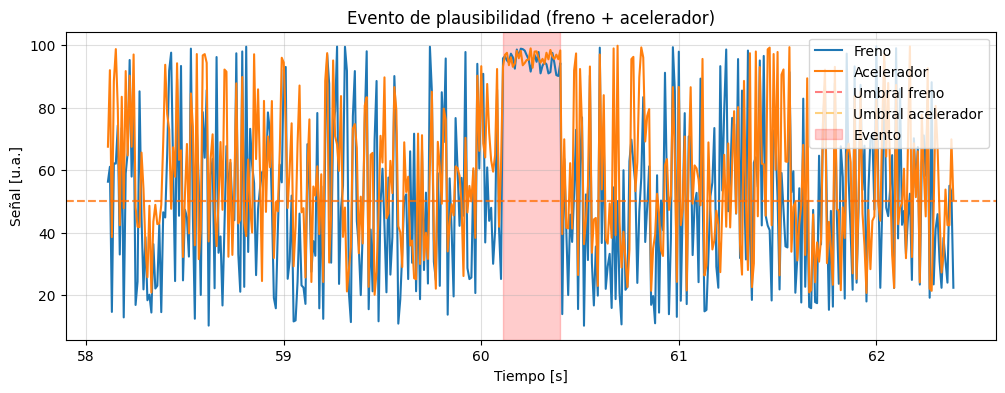

In [36]:
if len(long_events) > 0:
    # Tomar el primer evento para graficar
    s, e = long_events[0]
    start = max(0, s - 200)
    end = min(len(df), e + 200)
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df["time"].iloc[start:end], df["brake_pressure"].iloc[start:end], label="Freno")
    ax.plot(df["time"].iloc[start:end], df["throttle"].iloc[start:end], label="Acelerador")
    ax.axhline(BRAKE_THRESHOLD, color="red", linestyle="--", alpha=0.5, label="Umbral freno")
    ax.axhline(THROTTLE_THRESHOLD, color="orange", linestyle="--", alpha=0.5, label="Umbral acelerador")
    ax.axvspan(df.loc[s, "time"], df.loc[e, "time"], color="red", alpha=0.2, label="Evento")
    ax.set_xlabel("Tiempo [s]")
    ax.set_ylabel("Señal [u.a.]")
    ax.set_title("Evento de plausibilidad (freno + acelerador)")
    ax.grid(True, alpha=0.4)
    ax.legend()
    plt.show()
else:
    print("No se grafica ningún evento porque no se detectaron.")

La gráfica muestra los instantes en los que el freno y el acelerador están activos simultáneamente. Si se superan los umbrales durante más de 100 ms, se señala como un evento anómalo que debe ser revisado.

In [37]:
summary = pd.DataFrame({
    "Métrica": [
        "Número de muestras",
        "Duración del registro [s]",
        "Frecuencia de muestreo [Hz]",
        "Tipo de filtro",
        "Orden del filtro",
        "Frecuencia de corte [Hz]",
        "G combinada máxima filtrada [G]",
        "Timestamp de máxima G [s]",
        "G lateral izquierda (95%) [G]",
        "G lateral derecha (95%) [G]",
        "Asimetría lateral [%]",
        "Número de pérdidas de señal",
        "Número de posibles saturaciones",
        "Número de eventos de plausibilidad"
    ],
    "Valor": [
        n_samples,
        f"{duration:.2f}",
        FS,
        "Butterworth pasa-bajas",
        ORDER,
        FC,
        f"{max_g:.3f}",
        f"{max_time:.3f}",
        f"{G_left:.3f}" if not np.isnan(G_left) else "NaN",
        f"{G_right:.3f}" if not np.isnan(G_right) else "NaN",
        f"{asymmetry_percent:.2f}",
        len(nan_segments) + len(all_flat),
        len(sat_segments),
        len(long_events)
    ]
})
print("Resumen De Resultados")
print(summary.to_string(index=False))

Resumen De Resultados
                           Métrica                  Valor
                Número de muestras                  30000
         Duración del registro [s]                 300.00
       Frecuencia de muestreo [Hz]                  100.0
                    Tipo de filtro Butterworth pasa-bajas
                  Orden del filtro                      4
          Frecuencia de corte [Hz]                    5.0
   G combinada máxima filtrada [G]                  1.849
         Timestamp de máxima G [s]                 87.020
     G lateral izquierda (95%) [G]                  1.113
       G lateral derecha (95%) [G]                  0.055
             Asimetría lateral [%]                  95.05
       Número de pérdidas de señal                      7
   Número de posibles saturaciones                   1140
Número de eventos de plausibilidad                      1


Reporte técnico automático

In [38]:
# Construir el reporte
reporte = f"""
Reporte Técnico – Análisis De Telemetria

1. Acondicionamiento de señal:
   Se aplicó un filtro Butterworth pasa-bajas de orden {ORDER} y frecuencia de corte {FC} Hz, seleccionada a partir del análisis espectral que mostró que la dinámica principal se concentra por debajo de dicha frecuencia.

2. G combinada máxima filtrada:
   {max_g:.3f} G en el instante {max_time:.3f} s.

3. Diagrama G-G:
   La asimetría lateral calculada es de {asymmetry_percent:.2f} %, lo que indica {diagnosis}.

4. Posibles causas de la asimetría:
   Puede estar asociada con diferencias en la instrumentación (offset o montaje del IMU), en el set-up del vehículo (presión de neumáticos, alineación) o en el trazado del circuito.

5. Fallas de integridad del sensor:
   Se detectaron {len(nan_segments)} segmentos con NaN y {len(all_flat)} segmentos con flatline.
"""

if len(nan_segments) > 0:
    reporte += f"   El segmento más largo de NaN ocurre entre {df.loc[nan_segments[0][0],'time']:.3f} s y {df.loc[nan_segments[0][1],'time']:.3f} s.\n"
else:
    reporte += "   No se detectaron pérdidas significativas de señal por NaN.\n"

reporte += f"\n6. Eventos de plausibilidad (freno + acelerador):\n"
if len(long_events) > 0:
    reporte += f"   Se encontraron {len(long_events)} eventos de más de 100 ms de duración. El primero inicia en {df.loc[long_events[0][0],'time']:.3f} s y finaliza en {df.loc[long_events[0][1],'time']:.3f} s.\n"
else:
    reporte += "   No se detectaron eventos de este tipo bajo el criterio utilizado.\n"

reporte += """
7. Acciones recomendadas:
   - Verificar la integridad del cableado y conectores del IMU.
   - Revisar el rango de medición del acelerómetro y la alineación del sensor.
   - Correlacionar la asimetría con la configuración de neumáticos y suspensión.
   - Analizar los eventos de freno+acelerador en el contexto de la operación real del vehículo.
   -Calibrar los sensores y el filtro según las especificaciones técnicas.
"""

print(reporte)


Reporte Técnico – Análisis De Telemetria

1. Acondicionamiento de señal:
   Se aplicó un filtro Butterworth pasa-bajas de orden 4 y frecuencia de corte 5.0 Hz, seleccionada a partir del análisis espectral que mostró que la dinámica principal se concentra por debajo de dicha frecuencia.

2. G combinada máxima filtrada:
   1.849 G en el instante 87.020 s.

3. Diagrama G-G:
   La asimetría lateral calculada es de 95.05 %, lo que indica asimetría direccional significativa..

4. Posibles causas de la asimetría:
   Puede estar asociada con diferencias en la instrumentación (offset o montaje del IMU), en el set-up del vehículo (presión de neumáticos, alineación) o en el trazado del circuito.

5. Fallas de integridad del sensor:
   Se detectaron 6 segmentos con NaN y 1 segmentos con flatline.
   El segmento más largo de NaN ocurre entre 24.620 s y 24.620 s.

6. Eventos de plausibilidad (freno + acelerador):
   Se encontraron 1 eventos de más de 100 ms de duración. El primero inicia en 60.110 

**Conclusiones**

El pipeline desarrollado permite procesar y analizar señales de telemetría de un vehículo Formula SAE de forma sistemática. Se ha verificado la integridad de los datos, se han filtrado las aceleraciones para eliminar ruido no deseado, se ha calculado la aceleración combinada máxima y se ha generado el diagrama G‑G con su envolvente robusta. El diagnóstico automático de asimetría y la detección de anomalías proporcionan información valiosa para la puesta a punto y la seguridad del vehículo. El reporte técnico generado resume los hallazgos y sugiere acciones concretas, constituyendo una base objetiva para la toma de decisiones en el equipo de competición.